In [ ]:
import warnings
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm
import matplotlib.colors

from metpy.plots import USCOUNTIES
import cmocean

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import calendar
from tqdm.auto import tqdm
from dask.diagnostics import ProgressBar

warnings.filterwarnings("ignore")


# Display Formatting
def clean_fmt(x, pos):
    # if integer, print without .0
    if float(x).is_integer():
        return f"{int(x)}"
    # otherwise print a trimmed float
    return f"{x:.2f}".rstrip('0').rstrip('.')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 200      # notebook display

In [ ]:
# 1. Define region of interest - (South Florida Extent)

lon_min = -83
lon_max = -79.85
lat_max = 28.5
lat_min = 24.5

LON_SLICE = slice(lon_min, lon_max)
LAT_SLICE = slice(lat_min, lat_max)
BASE_DIR = '/bkirtman/tphoa'

def adjust_coords(ds, rename_time=False):
    if rename_time and 'Time' in ds.dims:
        ds = ds.rename({'Time': 'time'})
        
    # Standardize longitude to -180 to 180
    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby("lon")
    
    return ds.sel(lon=LON_SLICE, lat=LAT_SLICE)

# 2. Load and process datasets, convert to mm/day
# Observational/Reference Data
ds_nclimgrid = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/nclimgrid/nclimgrid-daily-prcp.*.nc'))

ds_imerg     = xr.open_mfdataset(f'{BASE_DIR}/imerg/year/precip_*_FL.nc4').transpose("time", "lat", "lon")
ds_imerg = ds_imerg.where(ds_nclimgrid['prcp'].notnull().any(dim='time').astype(float).interp(lon=ds_imerg.lon, lat=ds_imerg.lat, method='nearest') > 0)

ds_livneh    = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/LOCA-train/livneh-2015.prec.*.nc'))

# ds_pierce: renaming Time -> time
ds_pierce    = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/LOCA-train/livneh_unsplit_precip.*.nc'), rename_time=True)

# CCSM4 & CESM2 (Historical)
ds_ccsm4     = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/cesm/pr_day_CCSM4_historical_r6i1p1_*.nc')) * 86400.0

ds_cesm2_lens = xr.open_mfdataset(f'{BASE_DIR}/cesm/b.e21.BHISTcmip6.f09_g17.LE2-*.cam.h1.PRECT.1950-2014.nc', 
                                 concat_dim="ensemble", combine="nested", decode_times=True)
# ds_cesm2_lens unit conversion (m/s to mm/day)
ds_cesm2_lens = adjust_coords(ds_cesm2_lens) * 1000 * 86400.0

# LOCA Data
ds_loca_ccsm4 = adjust_coords(xr.open_dataset(f'{BASE_DIR}/LOCA/pr.CCSM4.historical.r6i1p1f1.1950-2005.LOCA_16thdeg.s_FL.nc'))

ds_loca_cesm2 = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/LOCA/pr.CESM2-LENS.historical.r*i1p1f1.1950-2014.LOCA_16thdeg_v20240915.s_east.nc',
                                                concat_dim="ensemble", combine="nested", decode_times=True)) 
ds_loca_cesm2 = ds_loca_cesm2 * 86400.0

## NWS COOP Stations

In [ ]:
nws_coop = pd.read_csv('/home/tphoa/FL-COOP-WBAN.csv')

mask = (nws_coop['Longitude'] >= lon_min) & (nws_coop['Longitude'] <= lon_max) & \
       (nws_coop['Latitude'] >= lat_min) & (nws_coop['Latitude'] <= lat_max)

nws_coop_fl = nws_coop[mask]

### Fig. 1 Annual Rx1day

In [ ]:
nclimgrid_annual_max_precip = ds_nclimgrid['prcp'].groupby('time.year').max(dim='time')
nclimgrid_annual_max_precip_mean = nclimgrid_annual_max_precip.mean(dim='year')

imerg_annual_max_precip = ds_imerg['precipitation'].groupby('time.year').max(dim='time')
imerg_annual_max_precip_mean = imerg_annual_max_precip.mean(dim='year')

livneh_annual_max_precip = ds_livneh['prec'].groupby('time.year').max(dim='time')
livneh_annual_max_precip_mean = livneh_annual_max_precip.mean(dim='year')

pierce_annual_max_precip = ds_pierce['PRCP'].groupby('time.year').max(dim='time')
pierce_annual_max_precip_mean = pierce_annual_max_precip.mean(dim='year')


ccsm4_annual_max_precip = ds_ccsm4['pr'].groupby('time.year').max(dim='time')
ccsm4_annual_max_precip_mean = ccsm4_annual_max_precip.mean(dim='year')

cesm2_annual_max_precip = ds_cesm2_lens['PRECT'].groupby('time.year').max(dim='time')
cesm2_annual_max_precip_ens = cesm2_annual_max_precip.mean(dim='ensemble')
cesm2_annual_max_precip_mean = cesm2_annual_max_precip_ens.mean(dim='year')

loca_ccsm4_annual_max_precip = ds_loca_ccsm4['pr'].groupby('time.year').max(dim='time')
loca_ccsm4_annual_max_precip_mean = loca_ccsm4_annual_max_precip.mean(dim='year')

loca_cesm2_annual_max_precip = ds_loca_cesm2['pr'].groupby('time.year').max(dim='time')
loca_cesm2_annual_max_precip_ens = loca_cesm2_annual_max_precip.mean(dim='ensemble')
loca_cesm2_annual_max_precip_mean = loca_cesm2_annual_max_precip_ens.mean(dim='year')


In [ ]:
datasets = {
    "nClimGrid": nclimgrid_annual_max_precip_mean,
    "IMERG": imerg_annual_max_precip_mean,
    "Livneh": livneh_annual_max_precip_mean,
    "Pierce": pierce_annual_max_precip_mean,
    "CCSM4": ccsm4_annual_max_precip_mean,
    "CESM2-LENS": cesm2_annual_max_precip_mean,
    "LOCA-CCSM4": loca_ccsm4_annual_max_precip_mean,
    "LOCA-CESM2-LENS": loca_cesm2_annual_max_precip_mean,
}

computed = {}
with ProgressBar():
    for name, ds in tqdm(datasets.items(), total=len(datasets), desc="Computing datasets"):
        computed[name] = ds.compute()

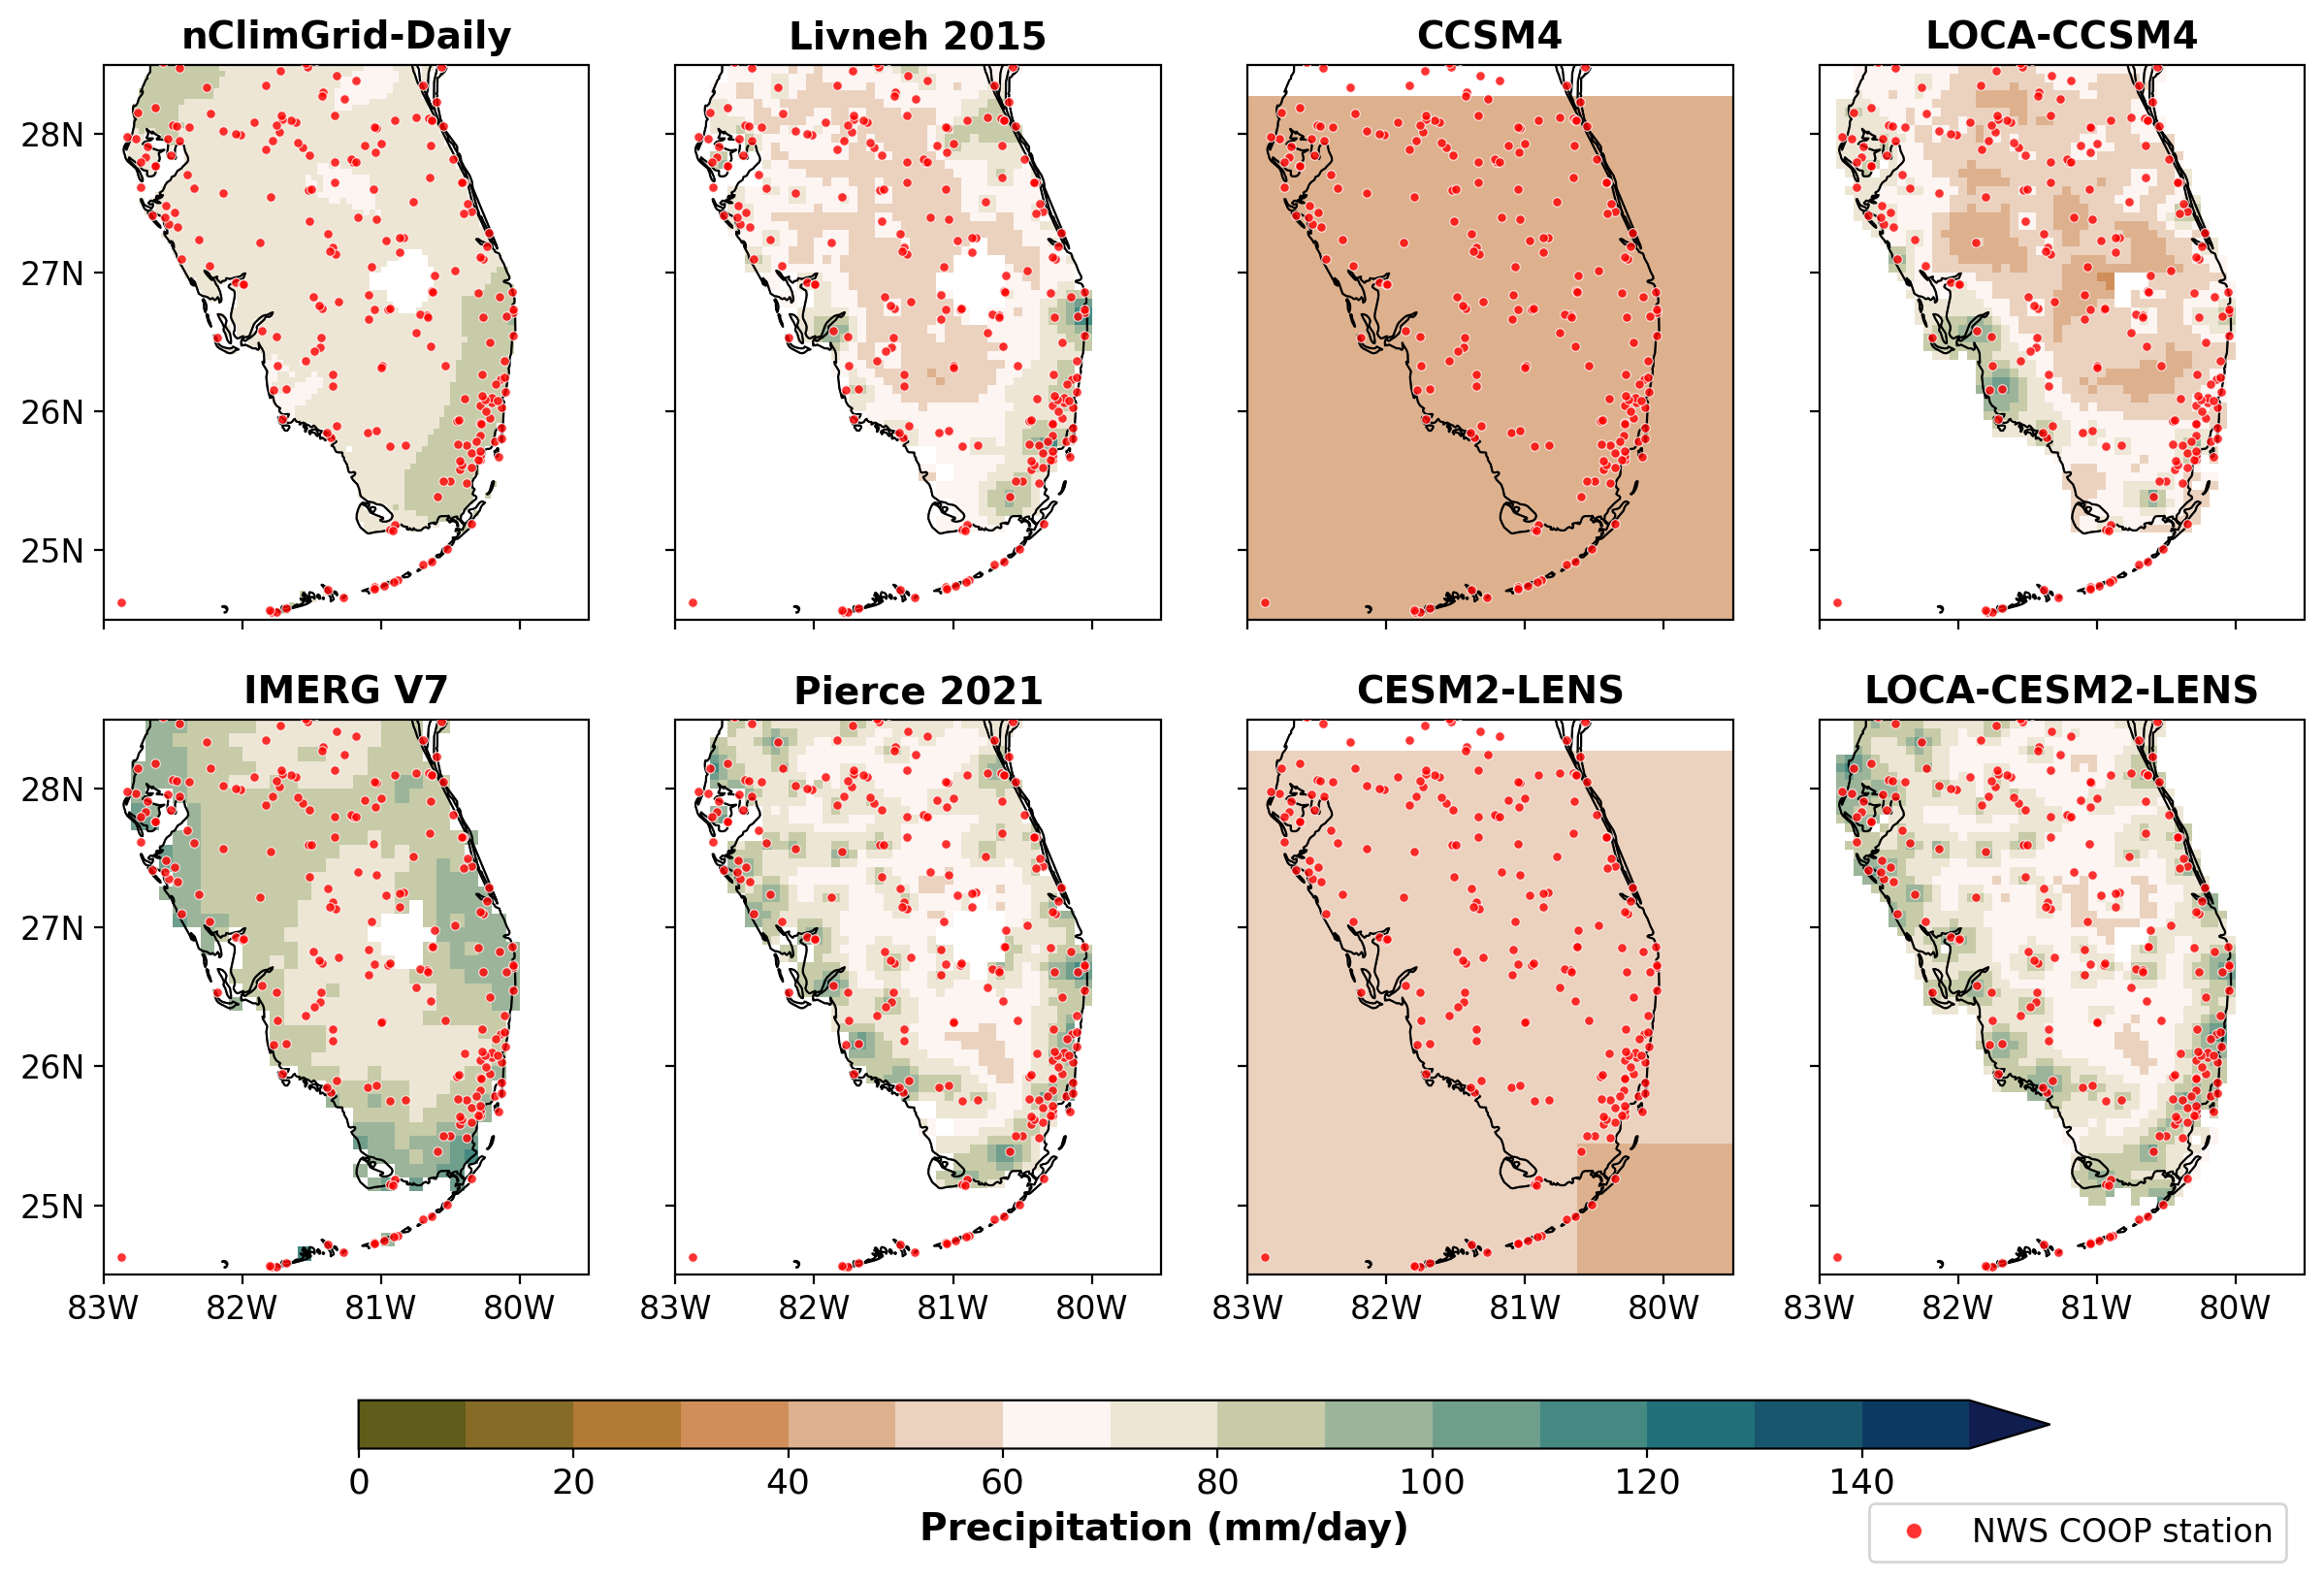

In [ ]:
#### PLOTTING CODES ####

row1 = [
    (computed["nClimGrid"], "nClimGrid-Daily"),
    (computed["Livneh"], "Livneh 2015"),
    (computed["CCSM4"], "CCSM4"),
    (computed["LOCA-CCSM4"], "LOCA-CCSM4")
]

row2 = [
    (computed["IMERG"], "IMERG V7"),
    (computed["Pierce"], "Pierce 2021"),
    (computed["CESM2-LENS"], "CESM2-LENS"),
    (computed["LOCA-CESM2-LENS"], "LOCA-CESM2-LENS")
]



fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(15, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Map boundaries and ticks
lon_ticks = [-83, -82, -81, -80]
lat_ticks = [25, 26, 27, 28]


colors = plt.get_cmap("cmo.tarn")(np.linspace(0.15, 1, 16))
levels = np.linspace(0, 150, 16) 
cmap, norm = matplotlib.colors.from_levels_and_colors(levels, colors, extend='max')

vmin, vmax = 0, 150

# ------------------------------------------------------------
# 3. Plot row 1
# ------------------------------------------------------------
for j, (data, title) in enumerate(row1):
    ax = axes[0, j]
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    mesh = ax.pcolormesh(
        data.lon.values,
        data.lat.values,
        data.squeeze().values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree(),
        zorder=1
    )

    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.5)

    ax.scatter(
        nws_coop_fl["Longitude"],
        nws_coop_fl["Latitude"],
        color="red",
        s=12,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.4,
        zorder=5,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f", degree_symbol=""))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f", degree_symbol=""))
    ax.tick_params(labelsize=12)

    ax.set_xticklabels([])
    if j != 0:
        ax.set_yticklabels([])

# ------------------------------------------------------------
# 4. Plot row 2
# ------------------------------------------------------------
for j, (data, title) in enumerate(row2):
    ax = axes[1, j]
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    mesh = ax.pcolormesh(
        data.lon.values,
        data.lat.values,
        data.squeeze().values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree(),
        zorder=1
    )

    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.5)

    ax.scatter(
        nws_coop_fl["Longitude"],
        nws_coop_fl["Latitude"],
        color="red",
        s=12,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.4,
        zorder=5,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f", degree_symbol=""))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f", degree_symbol=""))
    ax.tick_params(labelsize=12)

    if j != 0:
        ax.set_yticklabels([])


fig.subplots_adjust(
    top=0.93,
    bottom=0.12,
    wspace=0.06,
    hspace=0.18
)

cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    extend="max",
    pad=0.08,
    aspect=35,
    shrink=0.75
)
cbar.set_label("Precipitation (mm/day)", fontsize=14, fontweight="bold")
cbar.ax.tick_params(labelsize=13)

station_handle = plt.Line2D(
    [], [], linestyle="none", marker="o",
    markersize=6, markerfacecolor="red",
    markeredgecolor="white", markeredgewidth=0.6,
    alpha=0.8, label="NWS COOP station"
)

fig.legend(
    handles=[station_handle],
    loc="lower right",
    bbox_to_anchor=(0.89, 0.15),   # right, same line as cbar label
    frameon=True,
    fontsize=12,
)


plt.show()